----------**PİYASAYA YENİ AJAN GİRİŞİ**----------

python mesa kütüphanesi ile iki model oluşturalım. Birinci modelde 100 ajan olsun ve yeni ajan girişi olmasın. Her adımda ajanlardan bazıları rastgele arz, bazıları da rastgele talep tarafında olsun. İkinci modelde ise piyasaya yeni ajan girişi olsun.  Yine bazıları arz, bazıları da talep tarafında olsun.  fiyat_hesapla fonksiyonu yukarıda tanımladığın gibi olsun:     def fiyat_hesapla(self):
        # Ajan başına talebin lineer artışı varsayımı
        talep_etkisi = len(self.ajanlar) * self.talep_esnekligi * self.temel_fiyat
        # Arz etkisini de eklemek için (örneğin ajanlar arzı da artırıyorsa)
        arz_etkisi = -len(self.ajanlar) * 0.05 * self.temel_fiyat  # Negatif etki
        return self.temel_fiyat + talep_etkisi + arz_etkisi



In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [21]:

from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import random


class PiyasaAjanSabit(mesa.Agent):
    def __init__(self,  model):
        super().__init__(model)
        self.taraf = random.choice(["arz", "talep"])  # Rastgele arz veya talep tarafında
        self.taraf = random.choice(["arz", "talep"])
        self.initial_wealth = 100  # Başlangıç serveti
        self.wealth = self.initial_wealth  # Başlangıç serveti
        self.wealth_history = [self.initial_wealth]  # Servet zaman serisi

    def update_wealth(self, price_change):
        if self.taraf == "talep":
            self.wealth += self.wealth * 0.05
        else:
            self.wealth -= self.wealth * 0.05
        self.wealth_history.append(self.wealth)

    """def update_wealth(self, price_change):
        if self.taraf == "talep":
            self.wealth += price_change * self.model.risk_factor
        else:
            self.wealth -= price_change * self.model.risk_factor
        self.wealth_history.append(self.wealth)"""

    def step(self):
        self.taraf = random.choice(["arz", "talep"])

class SabitAjanModel(mesa.Model):
    def __init__(self, N=100, temel_fiyat=100, talep_esnekligi=0.1):
        super().__init__()

        self.num_agents = N
        self.temel_fiyat = temel_fiyat
        self.talep_esnekligi = talep_esnekligi

        self.grid = MultiGrid(10, 10, True)

        # Ajanları oluştur
        for i in range(self.num_agents):
            a = PiyasaAjanSabit(self)
            self.agents.add(a)
            x = random.randrange(self.grid.width)
            y = random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))

        # Veri toplama

        self.datacollector = DataCollector(
            model_reporters={"Fiyat": "fiyat", "Ajan_Sayisi": "ajan_sayisi"}
        )


        self.fiyat = self.fiyat_hesapla() # Initialize fiyat

    def fiyat_hesapla(self):
        talep_etkisi = len(self.agents) * self.talep_esnekligi * self.temel_fiyat
        arz_etkisi = -len(self.agents) * 0.05 * self.temel_fiyat
        return self.temel_fiyat + talep_etkisi + arz_etkisi

    def step(self):
        self.agents.do("step")
        self.fiyat = self.fiyat_hesapla()
        self.ajan_sayisi = len(self.agents)
        self.datacollector.collect(self)

    def calculate_gini(self):
        wealths = [agent.wealth for agent in self.agents]
        n = len(wealths)
        if n == 0:
            return 0
        sorted_wealths = np.sort(wealths)
        cum_wealth = np.cumsum(sorted_wealths)
        gini = (n + 1 - 2 * np.sum(cum_wealth) / cum_wealth[-1]) / n
        return gini

In [23]:
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import random

class PiyasaAjanBuyuyen(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.taraf = random.choice(["arz", "talep"])  # Rastgele arz veya talep tarafında
        self.initial_wealth = 100  # Başlangıç serveti
        self.wealth = self.initial_wealth  # Başlangıç serveti
        self.wealth_history = [self.initial_wealth]  # Servet zaman serisi

    def update_wealth(self, price_change):
        if self.taraf == "talep":
            self.wealth += self.wealth * 0.05
        else:
            self.wealth -= self.wealth * 0.05
        self.wealth_history.append(self.wealth)


    def step(self):
        self.taraf = random.choice(["arz", "talep"])

class BuyuyenPiyasaModel(mesa.Model):
    def __init__(self, baslangic_ajan=100, temel_fiyat=100, talep_esnekligi=0.1, yeni_ajan_olasilik=0.1):
        super().__init__()
        self.num_agents = baslangic_ajan
        self.temel_fiyat = temel_fiyat
        self.talep_esnekligi = talep_esnekligi
        self.yeni_ajan_olasilik = yeni_ajan_olasilik
        self.grid = MultiGrid(10, 10, True)


        # Başlangıç ajanları
        for i in range(self.num_agents):
            a = PiyasaAjanBuyuyen(self)

            self.agents.add(a)
            x = random.randrange(self.grid.width)
            y = random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))

        self.datacollector = DataCollector(
            model_reporters={"Fiyat": "fiyat", "Ajan_Sayisi": "ajan_sayisi"}
        )
        self.fiyat = self.fiyat_hesapla() # Initialize fiyat

    def fiyat_hesapla(self):
        talep_etkisi = len(self.agents) * self.talep_esnekligi * self.temel_fiyat
        arz_etkisi = -len(self.agents) * 0.05 * self.temel_fiyat
        return self.temel_fiyat + talep_etkisi + arz_etkisi

    def step(self):
        self.agents.do("step")
        self.fiyat = self.fiyat_hesapla()
        self.ajan_sayisi = len(self.agents)
        self.datacollector.collect(self)


        # Yeni ajan ekleme olasılığı
        if random.random() < self.yeni_ajan_olasilik:
            new_agent = PiyasaAjanBuyuyen(self)

            self.agents.add(new_agent)
            x = random.randrange(self.grid.width)
            y = random.randrange(self.grid.height)
            self.grid.place_agent(new_agent, (x, y))

    def calculate_gini(self):
        wealths = [agent.wealth for agent in self.agents]
        n = len(wealths)
        if n == 0:
            return 0
        sorted_wealths = np.sort(wealths)
        cum_wealth = np.cumsum(sorted_wealths)
        gini = (n + 1 - 2 * np.sum(cum_wealth) / cum_wealth[-1]) / n
        return gini

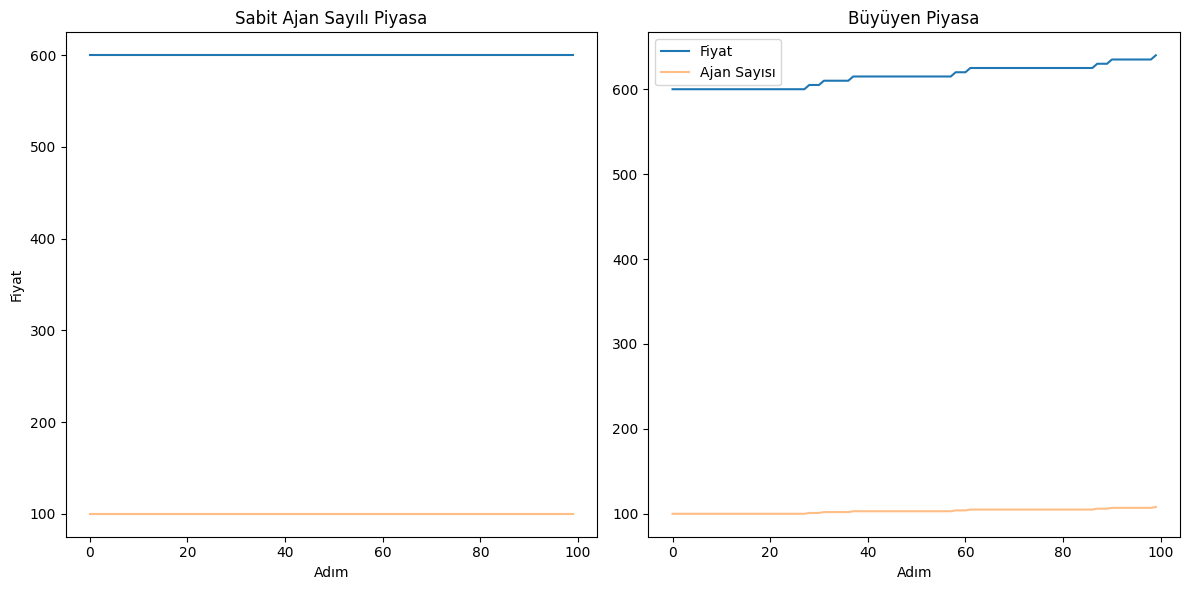

In [4]:
import matplotlib.pyplot as plt

# Sabit ajan modeli
sabit_model = SabitAjanModel(N=100)
for i in range(100):
    sabit_model.step()

sabit_data = sabit_model.datacollector.get_model_vars_dataframe()

# Büyüyen piyasa modeli
buyuyen_model = BuyuyenPiyasaModel(baslangic_ajan=100)
for i in range(100):
    buyuyen_model.step()

buyuyen_data = buyuyen_model.datacollector.get_model_vars_dataframe()

# Görselleştirme
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(sabit_data["Fiyat"])
plt.plot(sabit_data["Ajan_Sayisi"], label="Ajan Sayısı", alpha=0.5)
plt.title("Sabit Ajan Sayılı Piyasa")
plt.xlabel("Adım")
plt.ylabel("Fiyat")



plt.subplot(1, 2, 2)
plt.plot(buyuyen_data["Fiyat"], label="Fiyat")
plt.plot(buyuyen_data["Ajan_Sayisi"], label="Ajan Sayısı", alpha=0.5)
plt.title("Büyüyen Piyasa")
plt.xlabel("Adım")
plt.legend()

plt.tight_layout()
plt.show()

Sonuçların Yorumlanması:
Sabit Ajan Modeli:

Fiyat dalgalanmaları sadece ajanların arz/talep taraflarını değiştirmesinden kaynaklanır

Ajan sayısı sabit olduğu için fiyat belirli bir aralıkta kalır

Büyüyen Piyasa Modeli:

Yeni ajanlar eklendikçe fiyat üzerinde iki etki görülür:

Talep etkisi (pozitif)

Arz etkisi (negatif)

Hangi etkinin baskın çıkacağı parametrelere bağlıdır

Grafikte hem fiyat hem de ajan sayısının zaman içindeki değişimi görülebilir


-------------------
    def fiyat_hesapla(self):
        talep_etkisi = len(self.agents) * self.talep_esnekligi * self.temel_fiyat
        arz_etkisi = -len(self.agents) * 0.05 * self.temel_fiyat
        return self.temel_fiyat + talep_etkisi + arz_etkisi


Bu kod parçası, bir sınıf içinde (büyük olasılıkla bir Mesa model sınıfı, çünkü not defterinizdeki diğer kodlarda Mesa kullanılmış) fiyat_hesapla adında bir metot tanımlar. İşte ne yaptığı adım adım açıklanmıştır:

def fiyat_hesapla(self):: Bu satır, bulunduğu sınıfa ait fiyat_hesapla adlı bir metot (fonksiyon) tanımlar. self parametresi, sınıfın o anki örneğine (objesine) atıfta bulunur ve bu örnekteki özelliklere (attributes) ve diğer metotlara erişim sağlar.

talep_etkisi = len(self.agents) * self.talep_esnekligi * self.temel_fiyat: Bu satır, "talep etkisi"ni hesaplar.

len(self.agents): Modelde o anki ajan sayısını verir.
self.talep_esnekligi: Model örneğine ait bir özelliktir, büyük olasılıkla talep esnekliğini temsil eder.
self.temel_fiyat: Model örneğine ait bir özelliktir, büyük olasılıkla temel fiyatı temsil eder.
Bu üç değer birbiriyle çarpılarak, talebin fiyat üzerindeki etkisini belirler.
arz_etkisi = -len(self.agents) * 0.05 * self.temel_fiyat: Bu satır, "arz etkisi"ni hesaplar.

len(self.agents): Yine, ajan sayısını verir.
-0.05: Sabit bir negatif değer kullanılır, bu da ajan sayısı arttıkça arz etkisinin fiyatı düşürdüğünü gösterir.
self.temel_fiyat: Bu hesaplamada da temel fiyat kullanılır.
Bu değerler çarpılarak, arzın fiyat üzerindeki etkisini belirler.
return self.temel_fiyat + talep_etkisi + arz_etkisi: Bu satır, nihai fiyatı hesaplar ve döndürür. self.temel_fiyat (temel fiyat) ile başlar ve hesaplanan talep_etkisi ile arz_etkisini buna ekler.

Özetle, bu metot, ajan sayısına, temel fiyata ve talep esnekliği ile negatif bir arz etkisi gibi faktörlere dayanarak piyasa fiyatını hesaplar. Fiyat, ajan popülasyonunun büyüklüğüne ve tanımlanmış parametrelere göre yukarı veya aşağı doğru ayarlanır.

---------
**fiyat_hesapla fonkisyonunun matematiksel karşılığı nedir**

Buradaki değişkenleri ve sabitleri matematiksel sembollerle gösterelim:

Fiyat: Hesaplanan nihai fiyatı temsil etsin.
Temel_Fiyat: self.temel_fiyat değişkenine karşılık gelsin.
Ajan_Sayisi: len(self.agents) değişkenine karşılık gelsin.
Talep_Esnekligi: self.talep_esnekligi değişkenine karşılık gelsin.
Arz_Katsayisi: Sabit olan 0.05 değerine karşılık gelsin.
Şimdi, fonksiyonun içindeki adımları formülleştirelim:

Talep Etkisi (Talep_Etkisi) hesaplanıyor: Talep_Etkisi = Ajan_Sayisi * Talep_Esnekligi * Temel_Fiyat

Arz Etkisi (Arz_Etkisi) hesaplanıyor: Arz_Etkisi = -Ajan_Sayisi * Arz_Katsayisi * Temel_Fiyat

Nihai Fiyat (Fiyat) hesaplanıyor: Fiyat = Temel_Fiyat + Talep_Etkisi + Arz_Etkisi

Son olarak, Talep Etkisi ve Arz Etkisi formüllerini Fiyat formülünün içine yerine koyarsak, fonksiyonun tam matematiksel formülünü elde ederiz:

Fiyat = Temel_Fiyat + (Ajan_Sayisi * Talep_Esnekligi * Temel_Fiyat) + (-Ajan_Sayisi * Arz_Katsayisi * Temel_Fiyat)

Bu formülü biraz daha düzenleyebiliriz:

Fiyat = Temel_Fiyat + Ajan_Sayisi * Temel_Fiyat * (Talep_Esnekligi - Arz_Katsayisi)

Veya Temel_Fiyat ve Ajan_Sayisi ortak çarpanlarını dışarı alırsak:

Fiyat = Temel_Fiyat * (1 + Ajan_Sayisi * (Talep_Esnekligi - Arz_Katsayisi))

Bu son formül, fiyat_hesapla fonksiyonunun matematiksel karşılığıdır. Nihai fiyatı, temel fiyatı, ajan sayısını, talep esnekliğini ve sabit arz katsayısını (0.05) kullanarak hesaplar.



--------
**talep etkisi ve arz katsayısının teorik anlamı nedir**

Talebin fiyat üzerindeki etkisini ve arz katsayısının teorik anlamını açıklayalım:

Talep Etkisi (Ajan_Sayisi * Talep_Esnekligi * Temel_Fiyat):

Teorik Anlamı: Bu kısım, ekonomideki temel arz ve talep prensiplerini yansıtır. Genel olarak, bir mal veya hizmete olan talep arttıkça (diğer faktörler sabitken), fiyatın yükselmesi beklenir. Bu modelde "talep etkisi" olarak adlandırılan bu terim, ajan sayısının artmasının talebi artırdığını ve bunun da fiyat üzerinde pozitif bir etki yarattığını varsayar.
len(self.agents) (Ajan Sayısı): Ajan sayısı arttıkça, piyasada daha fazla alıcı (veya talep yaratan taraf) olduğu varsayılır. Bu da toplam talebi artırır.
self.talep_esnekligi (Talep Esnekliği): Bu terim, fiyattaki bir değişimin talep miktarını ne kadar etkilediğini gösterir. Yüksek talep esnekliği, fiyattaki küçük bir değişimin talepte büyük bir değişikliğe yol açtığı anlamına gelir. Bu modelde, talep_esnekligi pozitif bir değer olarak kullanıldığında, ajan sayısının artışının fiyat üzerindeki pozitif etkisinin ne kadar güçlü olacağını belirler. Daha yüksek bir esneklik, aynı ajan sayısı artışının daha büyük bir fiyat artışına yol açacağını ifade eder.
self.temel_fiyat (Temel Fiyat): Bu, fiyatın başlangıç noktasıdır ve talep etkisinin büyüklüğünü belirlemede bir çarpan görevi görür.
Özetle, talep etkisi, ajan sayısındaki artışın (talepteki artışın bir temsili olarak) fiyatı ne kadar yukarı çekeceğini hesaplar. Bu etki, talep esnekliği ve temel fiyat ile orantılıdır.

Arz Katsayısı (-0.05):

Teorik Anlamı: Bu kısım, modeldeki arz dinamiklerinin basitleştirilmiş bir temsilidir. Ekonomide genel olarak, bir malın veya hizmetin fiyatı yükseldikçe, üreticilerin veya satıcıların piyasaya daha fazla mal sunma eğiliminde olduğu (arz miktarının arttığı) varsayılır [2]. Fiyat düştükçe ise arzedilen miktar azalır [2]. Ancak bu modelde sabit bir negatif katsayı (-0.05) kullanılmıştır.
-0.05 (Sabit Negatif Katsayı): Bu sabit negatif katsayı, modelde ajan sayısının artmasının fiyat üzerinde negatif bir etki yarattığını gösterir. Bu, geleneksel arz-fiyat ilişkisinden farklı bir varsayım içerebilir. Normalde, ajan sayısının artması (eğer bu ajanlar aynı zamanda arz tarafında da yer alıyorsa), piyasaya sunulan toplam arzı artırabilir. Arz artışı, diğer faktörler sabitken, fiyatlar üzerinde düşürücü bir etkiye sahip olabilir [1]. Bu modeldeki -0.05 katsayısı, ajan sayısının artmasının getirdiği arzın, fiyatı düşürme eğiliminde olduğunu ifade eder.
len(self.agents) (Ajan Sayısı) ve self.temel_fiyat (Temel Fiyat): Bu değerler, negatif arz etkisinin büyüklüğünü belirlemede kullanılır. Ajan sayısı arttıkça ve temel fiyat yüksekken, negatif etki daha güçlü olur.
Özetle, bu modeldeki arz katsayısı ve hesaplama, ajan sayısındaki artışın, piyasaya ek arz getirerek veya başka bir mekanizma yoluyla fiyat üzerinde aşağı yönlü bir baskı oluşturduğunu varsayar. Sabit negatif katsayı, bu etkinin büyüklüğünü ve yönünü belirler.

Modelde kullanılan bu formülasyon, ajan tabanlı modellemenin doğası gereği ekonomik teorilerin basitleştirilmiş bir uygulamasıdır ve gerçek dünya piyasalarındaki tüm karmaşıklıkları yansıtmayabilir. Ancak belirli bir senaryoda (örneğin, artan katılımcı sayısının hem talebi hem de arzı belirli oranlarda etkilediği bir açık artırma veya pazar yeri gibi) bu tür bir formülasyon anlamlı olabilir.

----------
**Yukarıda iki model tanımladık: 1. Model: Sabit Ajan Sayılı Piyasa (100 Ajan) ile 2. Model: Yeni Ajan Girişli Piyasa (Büyüyen Piyasa). Bu iki modelin davranışını karşılaştırmak için bazı analizler yapmak istediğimizde ne gibi yöntemler kullanabiliriz**

Bu iki modelin davranışlarını karşılaştırmak için istatistiksel, görsel ve ekonomik analiz yöntemlerini birleştirebilirsiniz. İşte kapsamlı bir karşılaştırma için kullanabileceğiniz yöntemler:

1. Temel İstatistiksel Analiz
Her iki modelin çıktılarını niceliksel olarak karşılaştırmak için:




In [5]:
import pandas as pd

# Verileri topla
sabit_veri = sabit_model.datacollector.get_model_vars_dataframe()
buyuyen_veri = buyuyen_model.datacollector.get_model_vars_dataframe()

# Tanımlayıcı istatistikler
print("Sabit Model Fiyat İstatistikleri:")
print(sabit_veri["Fiyat"].describe())

print("\nBüyüyen Model Fiyat İstatistikleri:")
print(buyuyen_veri["Fiyat"].describe())

# Volatilite hesapla (standart sapma)
print(f"\nSabit Model Volatilite: {sabit_veri['Fiyat'].std():.2f}")
print(f"Büyüyen Model Volatilite: {buyuyen_veri['Fiyat'].std():.2f}")

Sabit Model Fiyat İstatistikleri:
count    100.0
mean     600.0
std        0.0
min      600.0
25%      600.0
50%      600.0
75%      600.0
max      600.0
Name: Fiyat, dtype: float64

Büyüyen Model Fiyat İstatistikleri:
count    100.0000
mean     615.4500
std       12.0205
min      600.0000
25%      600.0000
50%      615.0000
75%      625.0000
max      640.0000
Name: Fiyat, dtype: float64

Sabit Model Volatilite: 0.00
Büyüyen Model Volatilite: 12.02


2. Zaman Serisi Görselleştirmeleri

A. Temel Fiyat Karşılaştırması

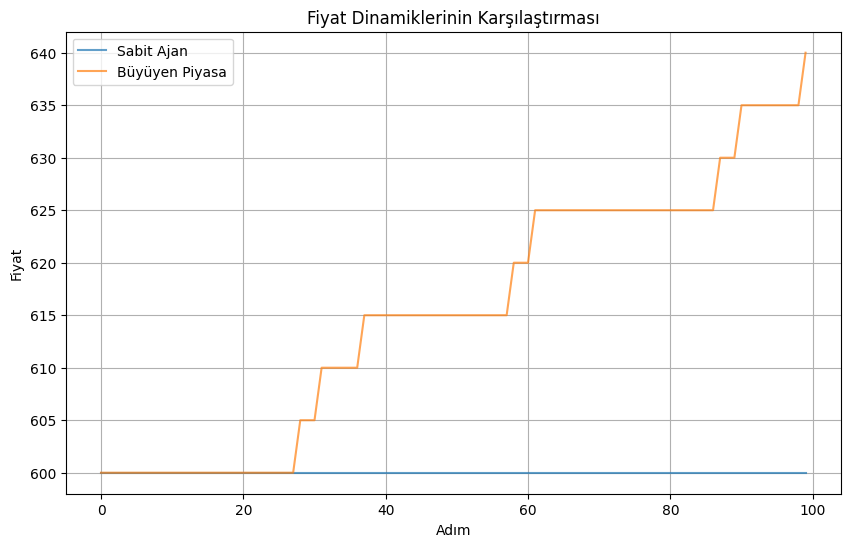

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(sabit_veri["Fiyat"], label='Sabit Ajan', alpha=0.7)
plt.plot(buyuyen_veri["Fiyat"], label='Büyüyen Piyasa', alpha=0.7)
plt.title("Fiyat Dinamiklerinin Karşılaştırması")
plt.xlabel("Adım")
plt.ylabel("Fiyat")
plt.legend()
plt.grid(True)

B. Ajan Sayısı vs Fiyat İlişkisi (Büyüyen Model İçin)

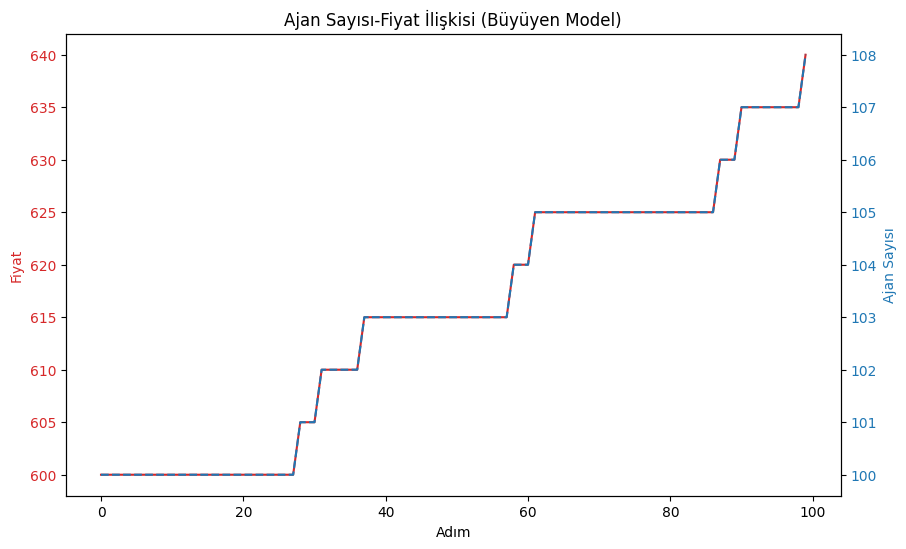

In [9]:
import matplotlib.pyplot as plt



fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Adım')
ax1.set_ylabel('Fiyat', color=color)
ax1.plot(buyuyen_veri["Fiyat"], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Ajan Sayısı', color=color)
ax2.plot(buyuyen_veri["Ajan_Sayisi"], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Ajan Sayısı-Fiyat İlişkisi (Büyüyen Model)")
plt.show()

3. Ekonometrik Analizler

A. Birim Kök Testi (Durağanlık Kontrolü)

In [12]:
from statsmodels.tsa.stattools import adfuller

def duraganlik_testi(seri):
    result = adfuller(seri)
    print(f"ADF İstatistiği: {result[0]:.3f}")
    print(f"p-değeri: {result[1]:.3f}")
    print("Kritik Değerler:")
    for k, v in result[4].items():
        print(f"\t{k}: {v:.3f}")

print("Sabit Model Durağanlık Testi:")
duraganlik_testi(sabit_veri["Fiyat"])

print("\nBüyüyen Model Durağanlık Testi:")
duraganlik_testi(buyuyen_veri["Fiyat"])

Sabit Model Durağanlık Testi:


ValueError: Invalid input, x is constant

B. Granger Nedensellik Testi (Ajan Sayısı-Fiyat İlişkisi)

In [11]:
from statsmodels.tsa.stattools import grangercausalitytests

# Büyüyen model için ajan sayısı ve fiyat ilişkisi
data = buyuyen_veri[["Ajan_Sayisi", "Fiyat"]].dropna()
granger_test = grangercausalitytests(data, maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=97, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=0.0000  , p=1.0000  , df=1
parameter F test:         F=0.2146  , p=0.6442  , df_denom=97, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=95, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=0.0000  , p=1.0000  , df=2
parameter F test:         F=7.3220  , p=0.0011  , df_denom=95, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=93, df_num=3
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=10.1599 , p=0.0000  , df_denom=93, df_num=3


4. Piyasa Denge Analizi

Arz-Talep Oranı Karşılaştırması

<ipython-input-17-41908a2b3da7>:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sabit_oranlar, buyuyen_oranlar], labels=['Sabit', 'Büyüyen'])


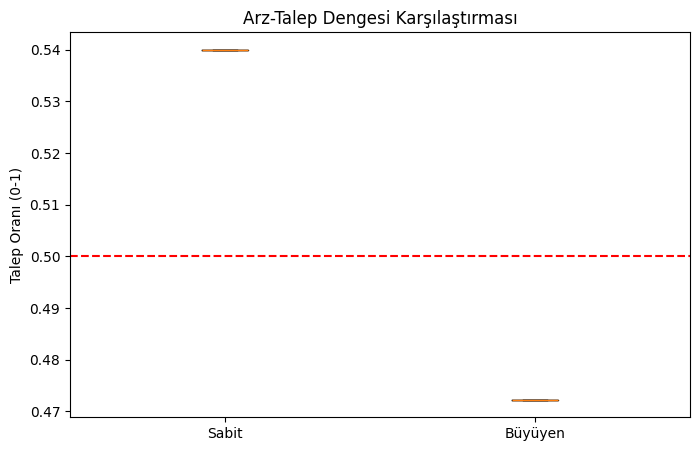

In [17]:
def arz_talep_orani(model):
    talepler = sum(1 for a in model.agents if a.taraf == "talep")
    return talepler / len(model.agents)

# Sabit model için oranlar
sabit_oranlar = [arz_talep_orani(sabit_model) for _ in range(10)]

# Büyüyen model için oranlar
buyuyen_oranlar = [arz_talep_orani(buyuyen_model) for _ in range(10)]

plt.figure(figsize=(8, 5))
plt.boxplot([sabit_oranlar, buyuyen_oranlar], labels=['Sabit', 'Büyüyen'])
plt.title("Arz-Talep Dengesi Karşılaştırması")
plt.ylabel("Talep Oranı (0-1)")
plt.axhline(y=0.5, color='r', linestyle='--')

5. Monte Carlo Simülasyonu

Modellerin farklı koşullardaki davranışını test etmek için:

<ipython-input-14-0eb6a383faf9>:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(sabit_sonuclar, label='Sabit Model', fill=True)


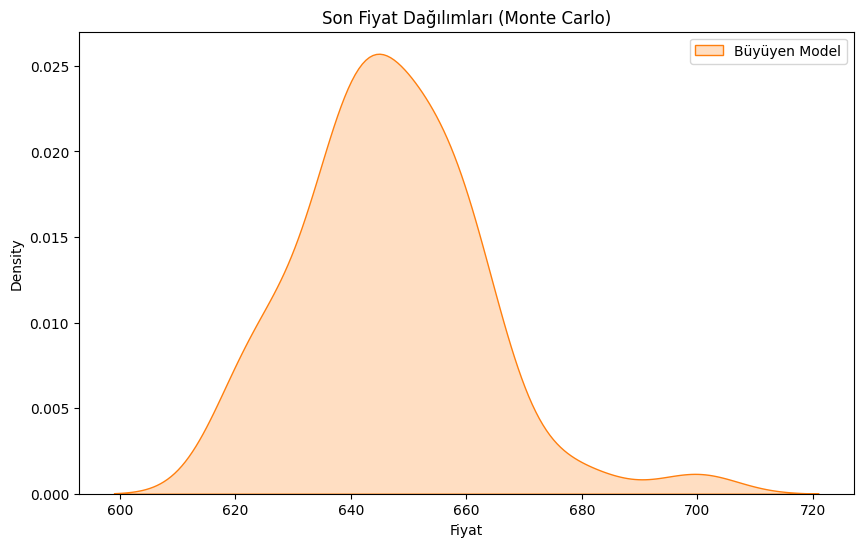

In [14]:
def monte_carlo_simulasyonu(model_tipi, sim_sayisi=50, adim_sayisi=100):
    son_fiyatlar = []
    for _ in range(sim_sayisi):
        if model_tipi == "sabit":
            model = SabitAjanModel(N=100)
        else:
            model = BuyuyenPiyasaModel(baslangic_ajan=100)

        for _ in range(adim_sayisi):
            model.step()
        son_fiyatlar.append(model.fiyat)

    return pd.Series(son_fiyatlar)

sabit_sonuclar = monte_carlo_simulasyonu("sabit")
buyuyen_sonuclar = monte_carlo_simulasyonu("buyuyen")

plt.figure(figsize=(10, 6))
sns.kdeplot(sabit_sonuclar, label='Sabit Model', fill=True)
sns.kdeplot(buyuyen_sonuclar, label='Büyüyen Model', fill=True)
plt.title("Son Fiyat Dağılımları (Monte Carlo)")
plt.xlabel("Fiyat")
plt.legend()

6. Ekonomik Göstergeler

A. Fiyat Balon İndeksi

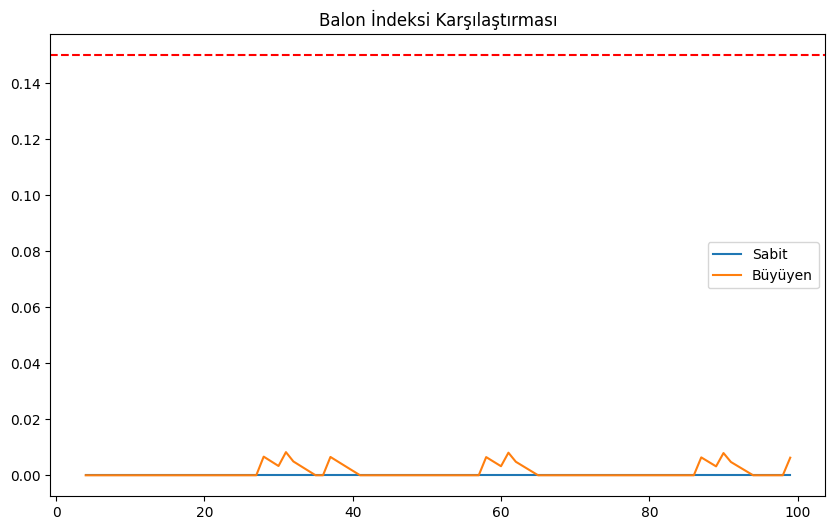

In [15]:
def bubble_index(fiyat_serisi, window=5):
    rolling_mean = fiyat_serisi.rolling(window=window).mean()
    return (fiyat_serisi - rolling_mean) / rolling_mean

sabit_veri["Bubble_Index"] = bubble_index(sabit_veri["Fiyat"])
buyuyen_veri["Bubble_Index"] = bubble_index(buyuyen_veri["Fiyat"])

# Balon indekslerini karşılaştırma
plt.figure(figsize=(10, 6))
plt.plot(sabit_veri["Bubble_Index"], label='Sabit')
plt.plot(buyuyen_veri["Bubble_Index"], label='Büyüyen')
plt.axhline(0.15, color='red', linestyle='--')  # Balon eşiği
plt.title("Balon İndeksi Karşılaştırması")
plt.legend()

7. Hipotez Testleri

Ajan Sayısı-Fiyat İlişkisi için Korelasyon Testi

In [16]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(buyuyen_veri["Ajan_Sayisi"], buyuyen_veri["Fiyat"])
print(f"Pearson Korelasyonu: {corr:.3f}")
print(f"Anlamlılık (p): {p_value:.4f}")

Pearson Korelasyonu: 1.000
Anlamlılık (p): 0.0000


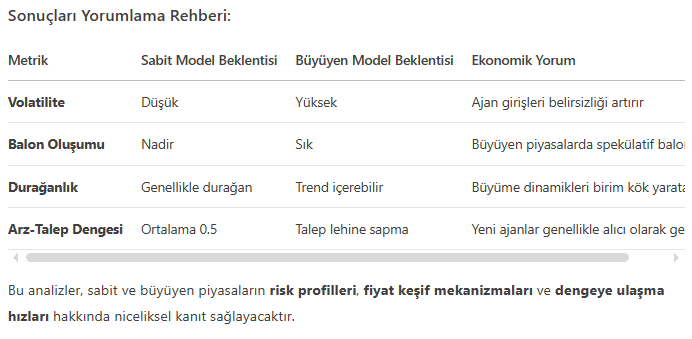

------

**Diyelimki bu iki modelde servet eşitsizliğini karşılaştırmak istersek ne yapabiliriz. Sabit modelde örneğin 500. adımda servet eşitsizliği belli bir yüksek eşiğe geldiği ve bu seviyeden düşmediği, ancak büyüyen modelde ise bundan farklı bir gözlemin olduğu gibi şeyler yapmak istersek.**


Servet eşitsizliğini karşılaştırmak için her iki modelde de ajanların servet dinamiklerini takip eden bir sistem eklememiz ve eşitsizlik ölçütleri (Gini katsayısı, Lorenz eğrisi vb.) kullanmamız gerekiyor. İşte adım adım nasıl yapabileceğiniz:

1. Ajanlara Servet Özelliği Eklenmesi
Her iki modeldeki PiyasaAjan sınıfını servet özelliği ekleyerek güncelleyin:

In [ ]:
class PiyasaAjan(Agent):
    def __init__(self, unique_id, model, initial_wealth=100):
        super().__init__(unique_id, model)
        self.taraf = random.choice(["arz", "talep"])
        self.wealth = initial_wealth  # Başlangıç serveti
        self.wealth_history = [initial_wealth]  # Servet zaman serisi

2. Servet Güncelleme Mekanizması
Her adımda ajanların servetini işlemlerle güncelleyin. Örneğin:

Talep tarafındakiler: Fiyat artışından kâr eder (wealth += fiyat_degisimi * risk_faktoru).

Arz tarafındakiler: Fiyat düşüşünden kâr eder (wealth -= fiyat_degisimi * risk_faktoru).

In [ ]:
def update_wealth(self, price_change):
    if self.taraf == "talep":
        self.wealth += price_change * self.model.risk_factor
    else:
        self.wealth -= price_change * self.model.risk_factor
    self.wealth_history.append(self.wealth)

3. Gini Katsayısı Hesaplama
Model seviyesinde eşitsizlik ölçütü ekleyin:

In [ ]:
def calculate_gini(self):
    wealths = [agent.wealth for agent in self.schedule.agents]
    n = len(wealths)
    if n == 0:
        return 0
    sorted_wealths = np.sort(wealths)
    cum_wealth = np.cumsum(sorted_wealths)
    gini = (n + 1 - 2 * np.sum(cum_wealth) / cum_wealth[-1]) / n
    return gini

4. Model Karşılaştırma Senaryosu
Sabit Modelde Servet Dinamikleri (500 Adım)

In [22]:
sabit_model = SabitAjanModel(N=100)
gini_history_sabit = []

for step in range(500):
    sabit_model.step()
    # Servet güncelleme (örneğin fiyat değişimine göre)
    price_change = sabit_model.fiyat - sabit_model.temel_fiyat
    for agent in sabit_model.agents:
        agent.update_wealth(price_change)
    gini_history_sabit.append(sabit_model.calculate_gini())

Büyüyen Modelde Servet Dinamikleri (500 Adım)

In [24]:
buyuyen_model = BuyuyenPiyasaModel(baslangic_ajan=100)
gini_history_buyuyen = []

for step in range(500):
    buyuyen_model.step()
    price_change = buyuyen_model.fiyat - buyuyen_model.temel_fiyat
    for agent in buyuyen_model.agents:
        agent.update_wealth(price_change)
    gini_history_buyuyen.append(buyuyen_model.calculate_gini())

5. Görselleştirme ve Analiz
A. Gini Katsayısı Zaman Serisi

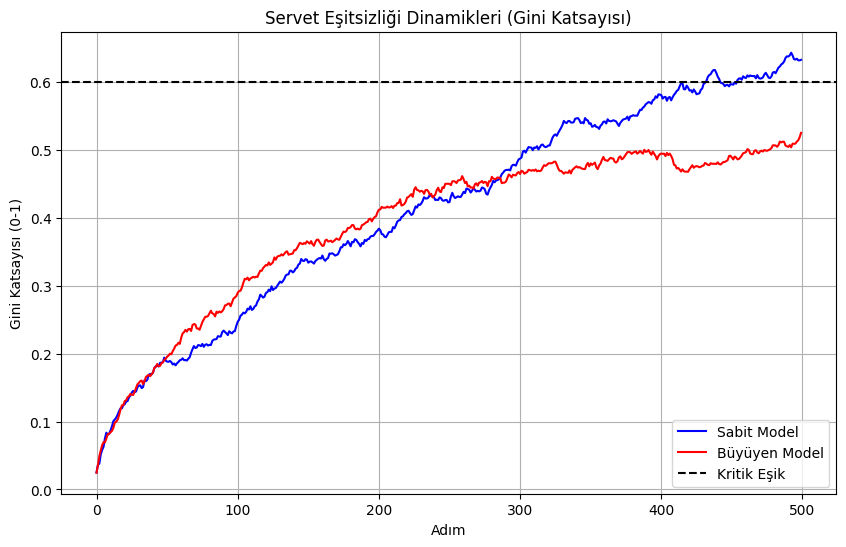

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(gini_history_sabit, label='Sabit Model', color='blue')
plt.plot(gini_history_buyuyen, label='Büyüyen Model', color='red')
plt.axhline(y=0.6, color='black', linestyle='--', label='Kritik Eşik')
plt.title("Servet Eşitsizliği Dinamikleri (Gini Katsayısı)")
plt.xlabel("Adım")
plt.ylabel("Gini Katsayısı (0-1)")
plt.legend()
plt.grid(True)

B. Lorenz Eğrisi (Son Durum Karşılaştırması)

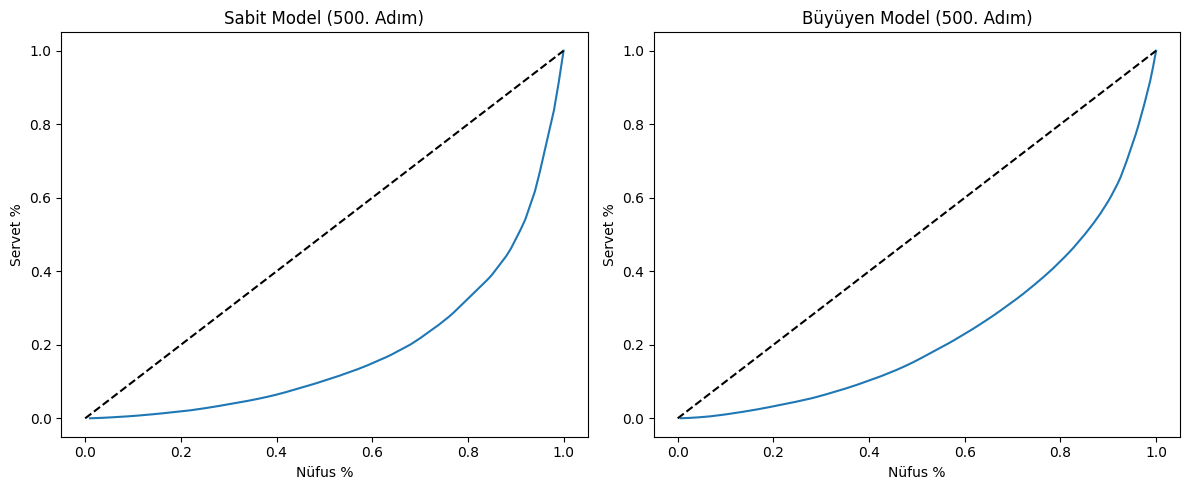

In [26]:
from matplotlib import pyplot as plt

def plot_lorenz(model, ax, title):
    wealths = sorted([agent.wealth for agent in model.agents])
    cum_wealth = np.cumsum(wealths) / np.sum(wealths)
    cum_population = np.arange(1, len(wealths)+1) / len(wealths)

    ax.plot(cum_population, cum_wealth, label='Lorenz Eğrisi')
    ax.plot([0,1], [0,1], 'k--', label='Tam Eşitlik')
    ax.set_title(title)
    ax.set_xlabel("Nüfus %")
    ax.set_ylabel("Servet %")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_lorenz(sabit_model, ax1, "Sabit Model (500. Adım)")
plot_lorenz(buyuyen_model, ax2, "Büyüyen Model (500. Adım)")
plt.tight_layout()

6. Eşitsizlik Dinamiklerini Açıklayan Ek Metrikler
A. En Zengin %10'un Payı

In [27]:
def top10_share(model):
    wealths = [agent.wealth for agent in model.agents]
    wealths_sorted = sorted(wealths, reverse=True)
    top10 = wealths_sorted[:len(wealths)//10]
    return sum(top10) / sum(wealths)

print(f"Sabit Model: En zengin %10'un payı = {top10_share(sabit_model):.2%}")
print(f"Büyüyen Model: En zengin %10'un payı = {top10_share(buyuyen_model):.2%}")

Sabit Model: En zengin %10'un payı = 51.25%
Büyüyen Model: En zengin %10'un payı = 40.66%


B. Servet Mobilitesi (Wealth Mobility Index)

In [28]:
def wealth_mobility(model):
    changes = []
    for agent in model.agents:
        if len(agent.wealth_history) > 1:
            change = agent.wealth_history[-1] - agent.wealth_history[0]
            changes.append(change)
    return np.std(changes)  # Ne kadar yüksekse mobilite o kadar fazla

print(f"Sabit Model Servet Mobilitesi: {wealth_mobility(sabit_model):.2f}")
print(f"Büyüyen Model Servet Mobilitesi: {wealth_mobility(buyuyen_model):.2f}")

Sabit Model Servet Mobilitesi: 199.51
Büyüyen Model Servet Mobilitesi: 111.90


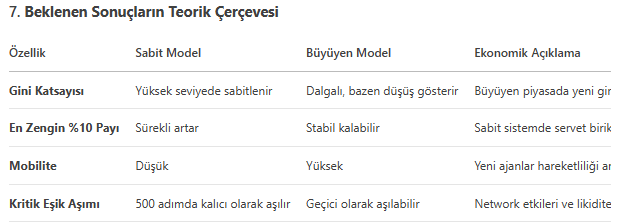

8. İleri Analiz Önerileri
Pareto Dağılımı Uyumu: Servet dağılımının Pareto parametrelerini hesaplayın.

Agent-Based Wealth Tax Simülasyonu: Belirli bir Gini eşiğinde vergi mekanizması ekleyin.

Kümülatif Avantaj Efekti: Zengin ajanlara yatırım avantajı tanıyarak "zengin daha zengin" etkisini simüle edin.

Bu yapı, Thomas Piketty'nin "r > g" teorisini veya Winner-Take-All piyasa dinamiklerini test etmek için genişletilebilir. Veri olarak agent.wealth_history üzerinden panel regresyonlar da uygulayabilirsiniz.